In [48]:
import NEXT
import os
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pynhd import WaterData, NLDI
from time import sleep
import warnings

# Prepare Environment

In [4]:
dirs = ["hist_data", "hrrr_data", "gfs_raw", "gfs_data", "forecasts"]
for d in dirs:
    if not os.path.exists(d):
        os.mkdir(d)

# Identify Sites

By default, the forecast runs for 1,000 HUC-12 pour points sampled from across the contiguous US. You can modify this by changing the site selection below and removing the cached site file. The sampling procedure is to select 1,000 different HUC-8s, then sample one HUC-12 from each. (The actual default dataset contains 935 sites.)

In [39]:
sitefile = "forecast_points.json"
run_sites = not os.path.exists(sitefile)

In [ ]:
def try_and_sleep(f):
    sleep(5)
    try:
        return f()
    except:
        return None

# Wait between calls because otherwise it tends to overload the API
if run_sites:
    huc6 = WaterData("wbd06")
    huc12 = WaterData("wbd12")
    all_huc6 = huc6.bybox((-125, 25, -65, 50))
    huc12_samp = pd.concat([
        try_and_sleep(lambda: huc12.bygeom(x.geometry).sample(n=50)) # get extra samples because some will crash
        for x in all_huc6.itertuples()
    ]).sample(n=1200)
    pps = NLDI().getfeature_byid("huc12pp", huc12_samp["huc12"])
    geodata = (huc12_samp.loc[:, ["geometry", "huc12", "areasqkm"]].
        rename(columns={"huc12": "id", "areasqkm": "area"}).
        merge(
            pd.DataFrame({
                "id": pps["identifier"],
                "lat": pps.geometry.y,
                "lon": pps.geometry.x
            }),
            on="id"
        )).dropna().sample(1000)
    geodata.loc[:, "area"] = geodata["area"] * 1e6 # km2 -> m2
    geodata.to_file(sitefile)

else:
    geodata = gpd.read_file(sitefile)

<Axes: >

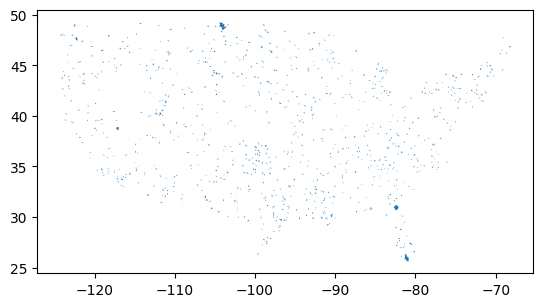

In [42]:
geodata.plot()

# Retrieve Historical Data

Humidity is retrieved from GridMet. Air temperature is from HRRR so that climatology will be more similar to GFS, for which archives are unavailable.

The below loops may crash periodically due to server errors. If so, just restart them, as they are set up to resume where they left off. The first round of full data retrieval takes several hours. Forecast retrievals are much faster.

In [ ]:
basepath = dirs[0] + "/"
with warnings.catch_warnings(action="ignore"):
    for row in geodata.itertuples():
        fn = basepath + row.id + ".csv"
        if not os.path.exists(fn):
            # note: site type "huc12" doesn't actually exist. It will internally convert to coordinates.
            try:
                NEXT.data.geom_full_data(row.id, "huc12", gpd.GeoSeries([row.geometry], crs=4326), row.lat, row.lon, row.area,
                                         "2015", "2025", "gridmet").to_csv(fn)
            except:
                print(row.id)

130402010203
100600070002
100901020210
150801010304
101000030204
180300010601
160202010900
040700070503
160502010104
170200110602
120100040503
020401040308
100500121004


In [ ]:
# pull HRRR temperature

# Retrieve Forecast Data

In [ ]:
# relevant code for GFS retrieval; needs some edits
# earlier = (datetime.date.today() - datetime.timedelta(6)).strftime("%Y%m%d")
# today = datetime.date.today().strftime("%Y%m%d")
# end = (datetime.date.today() + datetime.timedelta(16)).strftime("%Y-%m-%d")
# (geom, lat, lon, area) = NEXT.data.geom_fns[get_site_type(site)](site)
# recent_weath = pd.DataFrame(NEXT.wforecast.get_gfs_downloaded(geom, earlier, forecast_bp)).reset_index()
# fcst_weath = pd.DataFrame(NEXT.wforecast.get_gfs_downloaded(geom, today, forecast_bp)).reset_index()
# res = pd.concat([fcst_weath, recent_weath]).groupby("date", as_index=False)["tmax"].first().sort_values("date")
# res["lat"] = lat
# res["lon"] = lon
# res["id"] = site